# Titanic

## Initial EDA

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, recall_score

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

In [2]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic.shape

(891, 15)

In [4]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
# Deck has many missing values, we will drop it aloing with,  embark_town, embarked and alive (it is the same of survided)

In [6]:
titanic.columns.to_list()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [7]:
variables=[
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'class',
 'who',
 'adult_male',
 'alone']

In [8]:
target="survived"

In [9]:
X=titanic[variables]
y=titanic[target]

We desire to observe how is the distribution of variables, if there is an important variable that is unbalanced, we should try to stratify.

In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   pclass      891 non-null    int64   
 1   sex         891 non-null    object  
 2   age         714 non-null    float64 
 3   sibsp       891 non-null    int64   
 4   parch       891 non-null    int64   
 5   fare        891 non-null    float64 
 6   class       891 non-null    category
 7   who         891 non-null    object  
 8   adult_male  891 non-null    bool    
 9   alone       891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(3), object(2)
memory usage: 51.6+ KB


array([[<Axes: title={'center': 'pclass'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'sibsp'}>,
        <Axes: title={'center': 'parch'}>],
       [<Axes: title={'center': 'fare'}>, <Axes: >]], dtype=object)

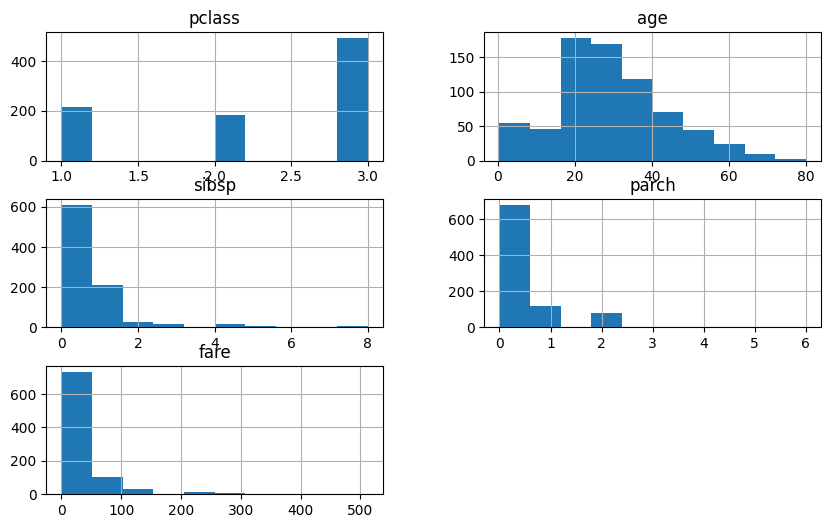

In [11]:
X.hist( figsize=(10, 6))

<Axes: >

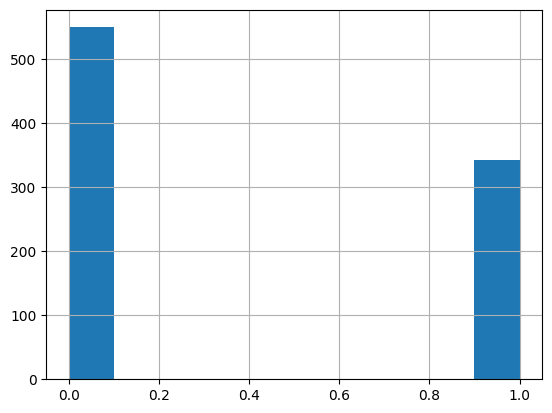

In [12]:
y.hist()

In [13]:
y.value_counts(normalize=True)

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## Transformers

We have to prepare trasnformer for both categorical and numeric variables

In [15]:
X_train.select_dtypes("number")

,pclass,age,sibsp,parch,fare
692,3,NaN,0,0,56.4958
481,2,NaN,0,0,0.0000
527,1,NaN,0,0,221.7792
855,3,18.0,0,1,9.3500
801,2,31.0,1,1,26.2500
...,...,...,...,...,...
359,3,NaN,0,0,7.8792
258,1,35.0,0,0,512.3292
736,3,48.0,1,3,34.3750
462,1,47.0,0,0,38.5000


In [16]:
numerical_variables=X_train.select_dtypes("number").columns.to_list()

In [17]:
numerical_variables

['pclass', 'age', 'sibsp', 'parch', 'fare']

In [18]:
X_train.select_dtypes(["object","category"])

,sex,class,who
692,male,Third,man
481,male,Second,man
527,male,First,man
855,female,Third,woman
801,female,Second,woman
...,...,...,...
359,female,Third,woman
258,female,First,woman
736,female,Third,woman
462,male,First,man


In [19]:
categorical_variables=X_train.select_dtypes(["object","category"]).columns.to_list()

In [20]:
numerical_transformer = Pipeline([ ("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()) ])

In [21]:
categorical_transformer = Pipeline(steps=[  ('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [22]:

preprocessor = ColumnTransformer([ ("num", numerical_transformer, numerical_variables), ("cat", categorical_transformer, categorical_variables) ])


### Random Forest

In [23]:
pipeline_rf=Pipeline([ ("preprocessor", preprocessor),("classifier",RandomForestClassifier(random_state=42) ) ])

In [24]:
param_grid_rf = { "classifier__n_estimators": [10,30,50, 100],
                  "classifier__max_depth": [None,2,5, 10, 20], 
                  "classifier__min_samples_split": [2, 5]
            }

In [25]:
cv_rf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [26]:
model_rf = GridSearchCV(estimator=pipeline_rf, param_grid=param_grid_rf, cv=cv_rf, scoring='recall', verbose=1, n_jobs=-1)
model_rf.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['pclass',
                                                                          'age',
                                                                          'sibsp',
                                                                          'parch',
                                                                          'fare']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'class',
                                                                          'who'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 2, 5, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [10, 30, 50, 100]},
             scoring='recall', verbose=1)

After changing the GridSearchCV scoring metric from accuracy to recall, the Random Forest model improved its ability to identify passengers who survived. The number of correctly predicted survivors increased from 50 to 53, while false negatives decreased from 19 to 16. Importantly, the number of false positives remained unchanged at 14. This means that optimizing for recall improved the detection of the positive class without increasing the number of incorrectly predicted survivors.

In [27]:
model_rf.best_params_

{'classifier__max_depth': None,
 'classifier__min_samples_split': 2,
 'classifier__n_estimators': 50}

In [28]:
y_pred_rf = model_rf.predict(X_test)
print("Report for random forest")
print("\n")
print(classification_report(y_test, y_pred_rf))

Report for random forest


              precision    recall  f1-score   support

           0       0.86      0.87      0.86       110
           1       0.79      0.77      0.78        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



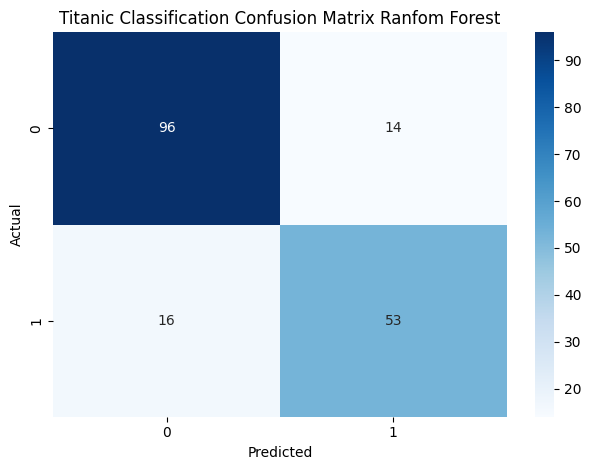

In [29]:
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(conf_matrix_rf, annot=True, cmap='Blues', fmt='d')

plt.title('Titanic Classification Confusion Matrix Ranfom Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

In [30]:
model_rf.best_estimator_['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_variables)

array(['sex_female', 'sex_male', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman'], dtype=object)

In [31]:
feature_importances = model_rf.best_estimator_['classifier'].feature_importances_
feature_names = numerical_variables + list(model_rf.best_estimator_['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_variables))

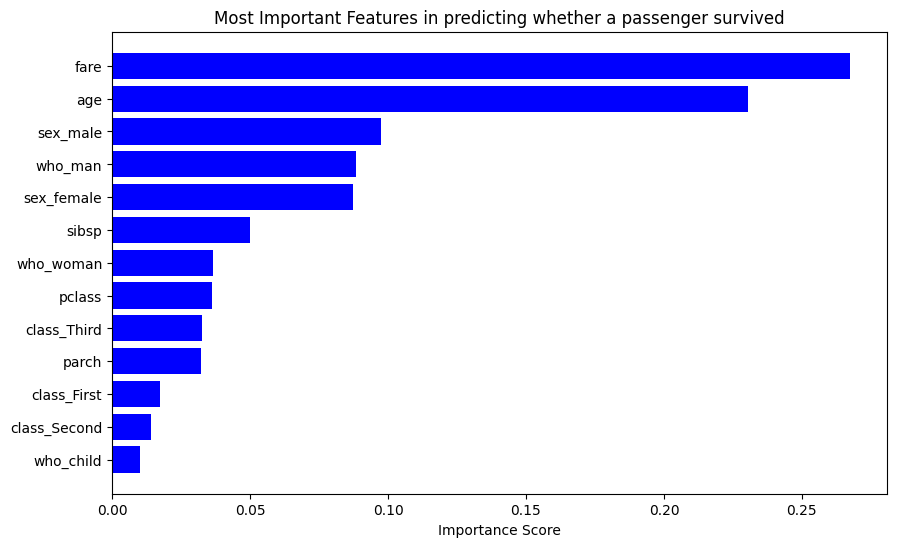


Test set accuracy: 76.81%


In [32]:
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='blue')
plt.gca().invert_yaxis() 
plt.title('Most Important Features in predicting whether a passenger survived')
plt.xlabel('Importance Score')
plt.show()

test_score = model_rf.score(X_test, y_test)
print(f"\nTest set score: {test_score:.2%}")

### LogisticRegression

Fitting 5 folds for each of 4 candidates, totalling 20 fits
{'classifier__class_weight': None, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}


Report for Logistic Regression


              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



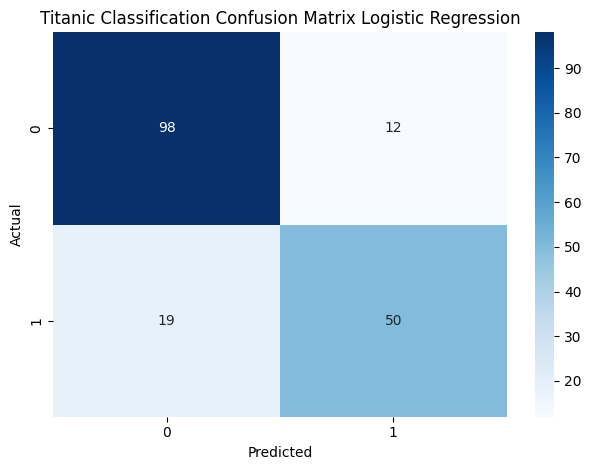

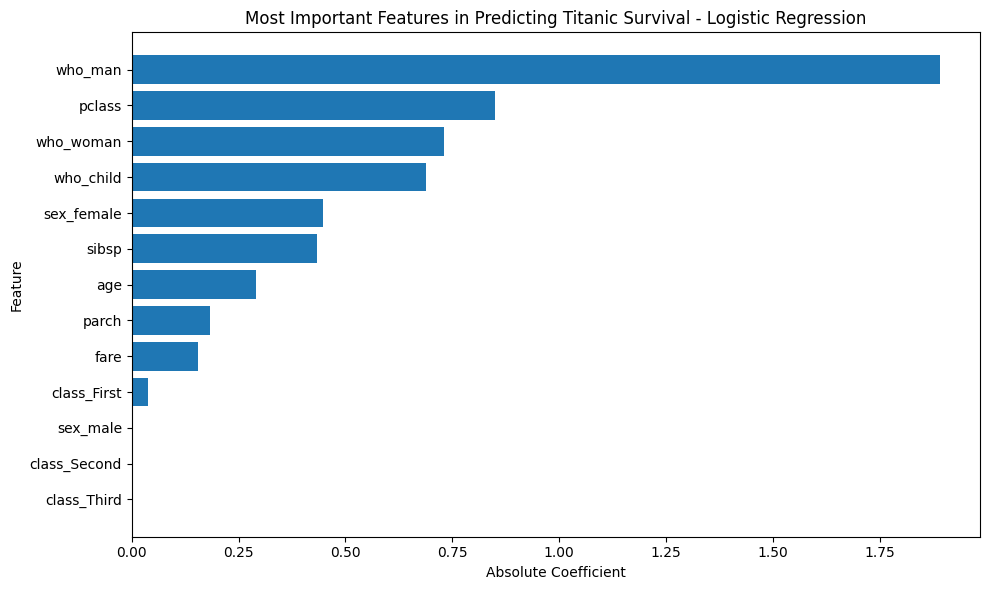


Test set accuracy: 76.34%


In [33]:
pipeline_lr=Pipeline([ ("preprocessor", preprocessor),("classifier",LogisticRegression(random_state=42) ) ])

param_grid_lr = {  'classifier__solver' : ['liblinear'],
                    'classifier__penalty': ['l1', 'l2'],
                    'classifier__class_weight' : [None, 'balanced']
            }
cv_lr = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

model_lr = GridSearchCV(estimator=pipeline_lr, param_grid=param_grid_lr, cv=cv_lr, scoring='f1', verbose=1, n_jobs=-1)
model_lr.fit(X_train, y_train)
print(model_lr.best_params_)
print("\n")
y_pred_lr = model_lr.predict(X_test)
print("Report for Logistic Regression")
print("\n")
print(classification_report(y_test, y_pred_lr))

conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(conf_matrix_lr, annot=True, cmap='Blues', fmt='d')

plt.title('Titanic Classification Confusion Matrix Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()


coefficients_lr = model_lr.best_estimator_["classifier"].coef_[0]

feature_names_lr = model_lr.best_estimator_["preprocessor"].get_feature_names_out()

coef_df_lr = pd.DataFrame({
    "Feature": feature_names_lr,
    "Coefficient": coefficients_lr,
    "Absolute Coefficient": np.abs(coefficients_lr)
})

coef_df_lr["Feature"] = (
    coef_df_lr["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

coef_df_lr = coef_df_lr.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    coef_df_lr["Feature"].head(15),
    coef_df_lr["Absolute Coefficient"].head(15)
)

plt.gca().invert_yaxis()
plt.title("Most Important Features in Predicting Titanic Survival - Logistic Regression")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

coef_df_lr.head(15)

test_score = model_lr.score(X_test, y_test)
print(f"\nTest set score: {test_score:.2%}")

### SVC

Fitting 5 folds for each of 42 candidates, totalling 210 fits
Best model


{'classifier__C': 15, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}


Report for SVC


              precision    recall  f1-score   support

           0       0.85      0.80      0.83       110
           1       0.71      0.78      0.74        69

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.79       179
weighted avg       0.80      0.79      0.79       179



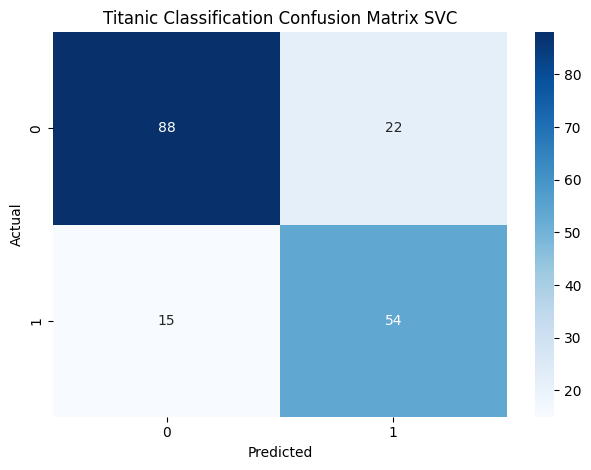


Test set accuracy for SVC: 79.33%


In [34]:
pipeline_svc=Pipeline([ ("preprocessor", preprocessor),("classifier",SVC(random_state=42) ) ])

param_grid_svc = [
    {
        "classifier__kernel": ["linear"],
        "classifier__C": [0.01,0.1, 1, 10,100],
        "classifier__class_weight": [None, "balanced"]
    },
    {
        "classifier__kernel": ["rbf"],
        "classifier__C": [3, 5, 7, 10, 14,15,16, 20],
        "classifier__gamma": ["scale", "auto"],
        "classifier__class_weight": [None, "balanced"]
    }
]

cv_svc = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

model_svc = GridSearchCV(estimator=pipeline_svc, param_grid=param_grid_svc, cv=cv_svc, scoring='f1', verbose=1, n_jobs=-1)
model_svc.fit(X_train, y_train)

print("Best model")
print("\n")
print(model_svc.best_params_)
print("\n")

y_pred_svc = model_svc.predict(X_test)
print("Report for SVC")
print("\n")
print(classification_report(y_test, y_pred_svc))

conf_matrix_svc = confusion_matrix(y_test, y_pred_svc)

plt.figure()
sns.heatmap(conf_matrix_svc, annot=True, cmap='Blues', fmt='d')

plt.title('Titanic Classification Confusion Matrix SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()


test_accuracy_svc = accuracy_score(y_test, y_pred_svc)

print(f"\nTest set score: {test_accuracy_svc:.2%}")

The dataset contains two classes: passengers who survived and passengers who did not survive. In this analysis, the main objective was not only to maximize overall accuracy, but to correctly identify passengers who did not survive. For that reason, recall for class 0 was considered the most important metric when selecting the final model.

Different models were trained and tuned using GridSearchCV. Although some models were optimized using F1 score, the final comparison focused on how well each model predicted class 0. Based on this criterion, Logistic Regression was selected as the final model because it achieved the highest recall for class 0, with a value of 0.89. This means that Logistic Regression was the best model for correctly identifying passengers who did not survive.
